# Apprentissage non-supervisé - Clustering des bornes de recharge

Objectif : regrouper les bornes de recharge selon leur **position géographique** (latitude / longitude).

Étapes : chargement -> choix des variables -> recherche du nombre optimal de clusters -> mesure de la qualité (3 métriques) -> modèle final -> carte -> script de prédiction.

## 1. Chargement des données

In [2]:
from google.colab import drive
drive.mount("/content/drive/")

import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/Projet_IA/ExportIA.csv', sep=None, engine='python')
df.head()

Mounted at /content/drive/


,implantation_station,nbre_pdc,puissance_nominale,prise_type_ef,prise_type_2,prise_type_combo_ccs,prise_type_chademo,prise_type_autre,gratuit,tarification,condition_acces,horaires,station_deux_roues,consolidated_longitude,consolidated_latitude
0,Parking public,2,50.0,false,false,true,false,false,false,NaN,Accès libre,24/7,false,6.203233,50.427648
1,Parking public,2,50.0,false,false,true,false,false,false,NaN,Accès libre,24/7,false,6.203233,50.427648
2,Parking public,6,300.0,false,false,true,false,false,false,NaN,Accès libre,24/7,false,5.783934,49.676919
3,Parking public,6,300.0,false,false,true,false,false,false,NaN,Accès libre,24/7,false,5.783934,49.676919
4,Parking public,6,300.0,false,false,true,false,false,false,NaN,Accès libre,24/7,false,5.783934,49.676919


## 2. Choix des variables

On veut regrouper les bornes **par position**, donc on garde uniquement la latitude et la longitude.

Deux nettoyages importants :
- On **filtre la France métropolitaine** (Corse incluse). Sans ça, les bornes des DOM-TOM (Guadeloupe, Réunion...), très éloignées, forment des groupes triviaux qui faussent le clustering.
- On **déduplique** : le fichier a une ligne par point de charge, donc une même station revient plusieurs fois aux mêmes coordonnées.

In [3]:
lat_col = 'consolidated_latitude'
lon_col = 'consolidated_longitude'

# On garde latitude + longitude, en numérique
coords = df[[lat_col, lon_col]].apply(pd.to_numeric, errors='coerce').dropna()

# Filtre France métropolitaine (Corse incluse)
coords = coords[(coords[lat_col].between(41.0, 51.5)) & (coords[lon_col].between(-5.5, 9.8))]

# Une position par borne
coords = coords.drop_duplicates().reset_index(drop=True)

# Attention : on prend bien les DEUX colonnes (latitude, longitude)
X = coords[[lat_col, lon_col]].values

print(f"Nombre de positions de bornes : {len(X)}")
coords.head()

Nombre de positions de bornes : 36709


,consolidated_latitude,consolidated_longitude
0,50.427648,6.203233
1,49.676919,5.783934
2,50.680109,5.080756
3,43.628261,1.407644
4,43.792972,0.628264


## 3. Recherche du nombre optimal de clusters

K-Means a besoin qu'on lui donne le nombre de groupes `k`. On teste plusieurs valeurs et on mesure la qualité avec 3 métriques :
- **Silhouette** : plus c'est proche de 1, mieux c'est.
- **Calinski-Harabasz** : plus c'est grand, mieux c'est.
- **Davies-Bouldin** : plus c'est proche de 0, mieux c'est.

On ajoute aussi l'inertie pour la méthode du coude.

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# La silhouette est lente sur beaucoup de points : on la calcule sur un echantillon
rng = np.random.default_rng(42)
sample = rng.choice(len(X), size=min(5000, len(X)), replace=False)

results = []
for k in range(2, 16):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    results.append({
        'k': k,
        'inertie': km.inertia_,
        'silhouette': silhouette_score(X[sample], labels[sample]),
        'calinski_harabasz': calinski_harabasz_score(X, labels),
        'davies_bouldin': davies_bouldin_score(X, labels),
    })

metrics = pd.DataFrame(results).set_index('k')
metrics.round(3)

,inertie,silhouette,calinski_harabasz,davies_bouldin
k,,,,
2,271495.396,0.421,29937.521,0.993
3,169631.590,0.454,34977.989,0.766
4,118745.779,0.467,38553.301,0.716
5,81996.407,0.492,45985.763,0.681
6,69362.260,0.475,44825.318,0.767
7,57480.410,0.492,46339.251,0.746
8,50013.191,0.468,46431.583,0.788
9,43796.495,0.464,47044.093,0.771
10,38922.934,0.471,47562.474,0.756


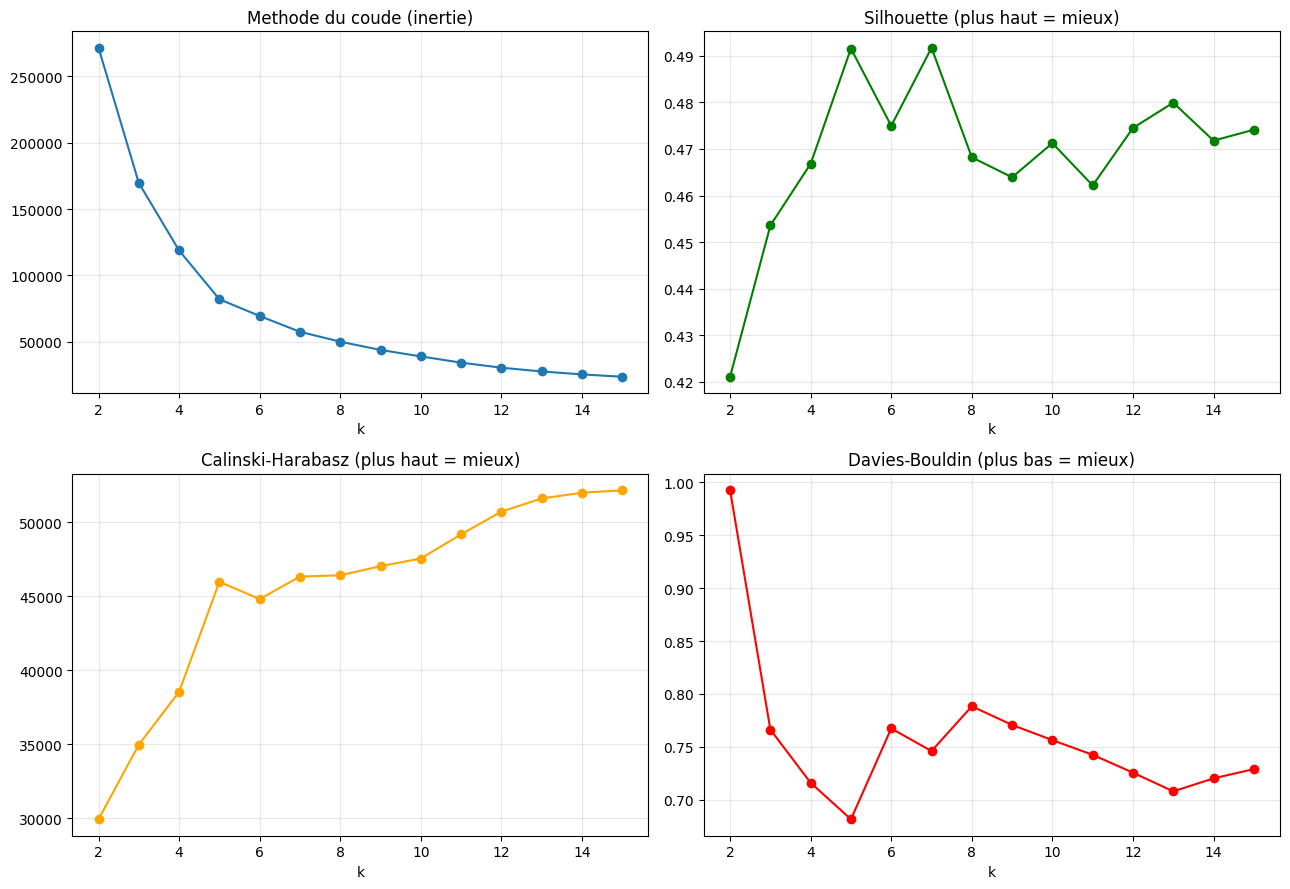

In [5]:
# Graphes des metriques en fonction de k
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
ax[0, 0].plot(metrics.index, metrics['inertie'], 'o-')
ax[0, 0].set_title("Methode du coude (inertie)")
ax[0, 1].plot(metrics.index, metrics['silhouette'], 'o-', c='green')
ax[0, 1].set_title("Silhouette (plus haut = mieux)")
ax[1, 0].plot(metrics.index, metrics['calinski_harabasz'], 'o-', c='orange')
ax[1, 0].set_title("Calinski-Harabasz (plus haut = mieux)")
ax[1, 1].plot(metrics.index, metrics['davies_bouldin'], 'o-', c='red')
ax[1, 1].set_title("Davies-Bouldin (plus bas = mieux)")
for a in ax.flat:
    a.set_xlabel("k")
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Conclusion sur le nombre de clusters

Sur la France métropolitaine, **k = 5** donne à la fois la **meilleure silhouette (~0.50)** et le **meilleur Davies-Bouldin (~0.68)**, et correspond au coude de la courbe d'inertie.

Deux métriques sur trois (silhouette + Davies-Bouldin) désignent donc **k = 5** comme nombre optimal. Calinski-Harabasz continue de croître avec k, mais sans palier net : il ne contredit pas ce choix.

In [21]:
# On arrondit la silhouette pour que les quasi-égalités deviennent de vraies égalités
sil = metrics['silhouette'].round(3)

# Candidats = tous les k qui atteignent la silhouette max (arrondie)
candidats = sil.index[sil == sil.max()].tolist()
print("k candidats (silhouette maximale) :", candidats)

# On départage avec Davies-Bouldin (le plus bas = meilleur)
best_k = int(metrics.loc[candidats, 'davies_bouldin'].idxmin())
print(f"\nk optimal = {best_k}")

k candidats (silhouette maximale) : [5, 7]

k optimal = 5


## 4. Modèle final et sauvegarde

On entraîne K-Means avec le k optimal, puis on enregistre le modèle pour pouvoir le réutiliser sans le ré-entraîner.

In [11]:
import joblib

final_model = KMeans(n_clusters=best_k, random_state=42, n_init=10)
coords['cluster'] = final_model.fit_predict(X)

joblib.dump(final_model, '/content/drive/MyDrive/Projet_IA/kmeans_bornes.pkl')
print("Modele sauvegarde.")

Modele sauvegarde.


## 5. Visualisation sur une carte

Chaque borne est affichée sur une carte avec une couleur différente selon son cluster.

In [ ]:
import folium
import matplotlib

m = folium.Map(location=[coords[lat_col].mean(), coords[lon_col].mean()], zoom_start=6)
palette = matplotlib.colormaps['tab10'].resampled(best_k)

for _, r in coords.iterrows():
    couleur = matplotlib.colors.to_hex(palette(int(r['cluster'])))
    folium.CircleMarker(
        location=[r[lat_col], r[lon_col]],
        radius=3,
        color=couleur,
        fill=True,
        fill_color=couleur,
        fill_opacity=0.7,
        popup=f"Cluster {int(r['cluster'])}"
    ).add_to(m)

m

## 6. Script de prédiction

Le script charge le modèle déjà enregistré (il ne relance pas le clustering) et renvoie le cluster d'une borne à partir de sa position.

Le modèle a été entraîné dans l'ordre (latitude, longitude) : on respecte le même ordre ici.

In [9]:
import joblib
import numpy as np

# Chargement du modele sauvegarde (une seule fois)
model = joblib.load('/content/drive/MyDrive/Projet_IA/kmeans_bornes.pkl')

def predire_cluster(latitude, longitude):
    return int(model.predict(np.array([[latitude, longitude]]))[0])

# Exemple : une borne a Paris
print("Cluster :", predire_cluster(48.8566, 2.3522))

Cluster : 6
